In [1]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.4.2

Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 83.0 MB/s eta 0:00:00


In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [3]:
X_train = pd.read_csv('/kaggle/input/bondora-final-final/X_train.csv')
y_train = pd.read_csv('/kaggle/input/bondora-final-final/y_train.csv')
X_test = pd.read_csv('/kaggle/input/bondora-final-final/X_test.csv')
y_test = pd.read_csv('/kaggle/input/bondora-final-final/y_test.csv')

# X_train = X_train.drop(columns = ['UserName'], axis=1)
# X_test = X_test.drop(columns = ['UserName'], axis=1)

In [4]:
X_train.shape

(61811, 30)

In [5]:
X_train.head()

,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,Age,Gender,AppliedAmount,Amount,Interest,...,MonthlyPaymentDay,Restructured,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan,MaturityDifference,LastMaturity_LastPaymentOn,LastMaturity_FirstPaymentDate,Rating_Encoded,Dayssincepreviousloan
0,-0.489696,-0.316462,-0.466274,-inline-,0.762821,0.020514,-0.669245,-0.881869,-0.898452,-0.440458,...,-0.590748,-0.50184,-0.624732,-0.585641,-0.214383,0.218546,-1.173360,-1.370206,0.280870,-0.420546
1,-0.926472,-0.316462,-0.277024,-kiisuke-,0.762821,0.020514,0.934364,-1.070404,-1.119692,-0.337601,...,-0.863566,-0.50184,-0.624732,-0.585641,-0.214383,0.218546,-1.208873,-1.659358,-0.927473,-0.420546
2,-0.926472,-0.316462,-0.382606,-kiisuke-,-1.310924,0.020514,0.934364,-1.102077,-1.156833,0.073825,...,-0.863566,-0.50184,0.045080,-0.482513,-0.214383,0.218546,-0.859007,-1.365360,-0.927473,0.727766
3,-0.926472,-0.316462,-0.414281,-kiisuke-,-1.310924,0.020514,0.934364,-1.111579,-1.168043,0.073825,...,-0.863566,-0.50184,0.714891,-0.399996,-0.214383,0.218546,-0.815602,-1.365360,-0.927473,-0.337032
4,-0.926472,-0.316462,0.847065,-party-power-,0.762821,0.020514,-0.669245,-0.733199,-0.723991,0.269766,...,-0.181522,-0.50184,-0.624732,-0.585641,-0.214383,0.218546,-1.053669,-1.660974,-0.927473,-0.420546


In [6]:
X_train.columns

Index(['BidsPortfolioManager', 'BidsApi', 'BidsManual', 'UserName',
       'NewCreditCustomer', 'Age', 'Gender', 'AppliedAmount', 'Amount',
       'Interest', 'LoanDuration', 'MonthlyPayment', 'Education',
       'EmploymentStatus', 'IncomeTotal', 'ExistingLiabilities',
       'LiabilitiesTotal', 'RefinanceLiabilities', 'DebtToIncome', 'FreeCash',
       'MonthlyPaymentDay', 'Restructured', 'NoOfPreviousLoansBeforeLoan',
       'AmountOfPreviousLoansBeforeLoan',
       'PreviousEarlyRepaymentsCountBeforeLoan', 'MaturityDifference',
       'LastMaturity_LastPaymentOn', 'LastMaturity_FirstPaymentDate',
       'Rating_Encoded', 'Dayssincepreviousloan'],
      dtype='object')

In [7]:
!pip install scikeras

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping

# Fusion_LSTM_MLP
# ===================== TIỀN XỬ LÝ DỮ LIỆU =====================
def preprocess_sequential_data(sequences, pad_value=-999, maxlen=6):
    return pad_sequences(sequences, padding='post', dtype='float32', value=pad_value, maxlen=maxlen)

def process_user_sequences(data, user_column, pad_value=-999, maxlen=6):

    if user_column not in data.columns:
        raise ValueError(f"Column `{user_column}` not found in data!")

    # Select numeric columns (excluding user_column if it's numeric)
    numeric_columns = data.select_dtypes(include=['float32', 'float64']).columns
    if user_column in numeric_columns:
        numeric_columns = numeric_columns.drop(user_column)

    sequences = []

    grouped = data.groupby(user_column, sort=False)  # giữ đúng thứ tự gốc

    for _, group in grouped:
        features = group[numeric_columns].values
        for i in range(1, len(features) + 1):
            sequences.append(features[:i])  # growing window

    padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding='post',
                                     dtype='float32', value=pad_value)

    return padded_sequences, numeric_columns

# ===================== XÂY DỰNG CÁC MÔ HÌNH =====================
def build_lstm_model(input_shape, lstm_units=128, dense_units=32, dropout_rate=0.2, padding_value=-999):
    inputs = keras.Input(shape=input_shape)
    masked = layers.Masking(mask_value=padding_value)(inputs)
    x = layers.LSTM(lstm_units, return_sequences=False, stateful=False)(masked)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    return Model(inputs, x, name="LSTM_Model")

def build_mlp_model(input_dim, hidden_units=[64, 32], dropout_rate=0.2):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for units in hidden_units:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)
    return Model(inputs, x, name="MLP_Model")

def build_fusion_model(seq_input_shape, tab_input_dim, lstm_params=None, mlp_params=None, padding_value=-999):
    if lstm_params is None:
        lstm_params = {'lstm_units': 128, 'dense_units': 64, 'dropout_rate': 0.2, 'padding_value': padding_value}
    if mlp_params is None:
        mlp_params = {'hidden_units': [128, 64], 'dropout_rate': 0.2}

    lstm_model = build_lstm_model(seq_input_shape, **lstm_params)
    mlp_model = build_mlp_model(tab_input_dim, **mlp_params)

    seq_input = keras.Input(shape=seq_input_shape, name="Sequential_Input")
    tab_input = keras.Input(shape=(tab_input_dim,), name="Tabular_Input")

    seq_output = lstm_model(seq_input)
    tab_output = mlp_model(tab_input)

    merged = layers.Concatenate()([seq_output, tab_output])

    final_output = layers.Dense(1, activation='sigmoid')(merged)
    model = Model(inputs=[seq_input, tab_input], outputs=final_output, name="Fusion_Model")

    return model

# ===================== LỚP BỌC MÔ HÌNH =====================
class HybridModel:
    def __init__(self, seq_shape, tab_dim, user_column='UserName', lstm_params=None, mlp_params=None, padding_value=0.0):
        self.user_column = user_column
        self.padding_value = padding_value
        self.model = build_fusion_model(seq_shape, tab_dim, lstm_params, mlp_params, padding_value)

    def preprocess_data(self, df):
        df = df.copy()
        if self.user_column in df.columns:
            user_data = df[[self.user_column]]  # Keep user column separately
        else:
            user_data = None

        df = df.select_dtypes(include=['number']).astype(np.float32)  # Convert to float32

        padded_sequences, feature_columns = process_user_sequences(df.join(user_data), self.user_column, pad_value=self.padding_value)
        if feature_columns.empty:
            raise ValueError("No numeric features found for processing.")

        tabular_features = df[feature_columns].values.astype(np.float32)  # Ensure float32 dtype
        return padded_sequences, tabular_features

    def train(self, X_train, y_train, epochs=100, batch_size=32, optimizer='adam', patience=10):
        X_seq_train, X_tab_train = self.preprocess_data(X_train)

        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

        self.model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        self.model.fit(
            [X_seq_train, X_tab_train], y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stopping]
        )

    def predict(self, X_test):
        X_seq_test, X_tab_test = self.preprocess_data(X_test)
        return self.model.predict([X_seq_test, X_tab_test])

In [9]:
# ['concatenate', 'add', 'multiply', 'average', 'dot']
model = build_fusion_model(seq_input_shape=(6, 22), tab_input_dim=22)
model.summary()

Model: "Fusion_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Sequential_Input          │ (None, 6, 22)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Tabular_Input             │ (None, 22)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ LSTM_Model (Functional)   │ (None, 64)             │         85,568 │ Sequential_Input[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ MLP_Model (Functional)    │ (None, 64)             │         11,200 │ Tabular_Input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 128)            │              0 │ LSTM_Model[0][0],      │
│                           │                        │                │ MLP_Model[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 1)              │            129 │ concatenate[0][0]      │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 96,897 (378.50 KB)

 Trainable params: 96,897 (378.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

#Conditional_LSTM_MLP
# ===================== 1. TIỀN XỬ LÝ DỮ LIỆU =====================
def preprocess_sequential_data(sequences, pad_value=-999, maxlen=6):
    return pad_sequences(sequences, padding='post', dtype='float32', value=pad_value, maxlen=maxlen)

def process_user_sequences(data, user_column, pad_value=-999, maxlen=6):

    if user_column not in data.columns:
        raise ValueError(f"Column `{user_column}` not found in data!")

    # Select numeric columns (excluding user_column if it's numeric)
    numeric_columns = data.select_dtypes(include=['float32', 'float64']).columns
    if user_column in numeric_columns:
        numeric_columns = numeric_columns.drop(user_column)

    sequences = []

    grouped = data.groupby(user_column, sort=False)  # giữ đúng thứ tự gốc

    for _, group in grouped:
        features = group[numeric_columns].values
        for i in range(1, len(features) + 1):
            sequences.append(features[:i])  # growing window

    padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding='post',
                                     dtype='float32', value=pad_value)

    return padded_sequences, numeric_columns

# ===================== 2. XÂY DỰNG MÔ HÌNH =====================


def build_conditional_fusion_model(seq_input_shape, tab_input_dim, lstm_params=None, mlp_params=None, padding_value=-999):
    """
    Creates a conditional fusion model combining LSTM for sequential data and MLP for tabular data.
    """
    # Default hyperparameters
    if lstm_params is None:
        lstm_params = {'lstm_units': 128, 'dense_units': 64, 'dropout_rate': 0.2}  
    if mlp_params is None:
        mlp_params = {'hidden_units': [128, 64], 'dropout_rate': 0.2}

    # Define Inputs
    seq_input = Input(shape=seq_input_shape, name="Sequential_Input")
    tab_input = Input(shape=(tab_input_dim,), name="Tabular_Input")

    # LSTM Processing
    lstm_out = LSTM(lstm_params['lstm_units'], return_sequences=False)(seq_input)
    lstm_out = Dense(lstm_params['dense_units'], activation='relu')(lstm_out)
    lstm_out = Dropout(lstm_params['dropout_rate'])(lstm_out)

    # MLP Processing (Ensure Output Dimension Matches LSTM)
    mlp_out = Dense(mlp_params['hidden_units'][0], activation='relu')(tab_input)
    mlp_out = Dropout(mlp_params['dropout_rate'])(mlp_out)
    mlp_out = Dense(lstm_params['dense_units'], activation='relu')(mlp_out)  # Ensure same size as LSTM output

    # ✅ Apply Dense Layer Outside Lambda to Ensure Matching Shapes
    tab_output_aligned = Dense(lstm_params['dense_units'], activation='relu')(mlp_out)  # Ensure same size as LSTM output

    # Conditional Fusion
    def conditional_merge(inputs):
        seq_output, tab_output, seq_input = inputs
        seq_length = tf.reduce_sum(tf.cast(tf.not_equal(seq_input, padding_value), tf.float32), axis=1)[:, 0]
        condition = tf.expand_dims(tf.greater(seq_length, 1), axis=-1)

        return tf.where(condition, seq_output, tab_output)

    # Apply conditional fusion
    selected_output = Lambda(conditional_merge, output_shape=lambda input_shapes: input_shapes[0])([lstm_out, tab_output_aligned, seq_input])

    # Final Prediction
    output = Dense(1, activation='sigmoid')(selected_output)

    return Model(inputs=[seq_input, tab_input], outputs=output, name="Conditional_Fusion_Model")

# ===================== 3. LỚP HUẤN LUYỆN MÔ HÌNH =====================
class HybridConditionalModel:
    def __init__(self, seq_shape, tab_dim, user_column='UserName', lstm_params=None, mlp_params=None):
        self.user_column = user_column
        self.model = build_conditional_fusion_model(seq_shape, tab_dim, lstm_params, mlp_params)

    def preprocess_data(self, df):
        df = df.copy()
        if self.user_column in df.columns:
            user_data = df[[self.user_column]]
        else:
            user_data = None

        df = df.select_dtypes(include=['number']).astype(np.float32)

        padded_sequences, feature_columns = process_user_sequences(df.join(user_data), self.user_column)
        if feature_columns.empty:
            raise ValueError("No numeric features found for processing.")

        tabular_features = df[feature_columns].values.astype(np.float32)
        return padded_sequences, tabular_features

    def train(self, X_train, y_train, epochs=100, batch_size=32, optimizer='adam', patience=10):
        X_seq_train, X_tab_train = self.preprocess_data(X_train)

        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

        self.model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        self.model.fit(
            [X_seq_train, X_tab_train], y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stopping]
        )

    def predict(self, X_test):
        X_seq_test, X_tab_test = self.preprocess_data(X_test)
        return self.model.predict([X_seq_test, X_tab_test])



In [11]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Multiply, Lambda, Add

# LSTM
# ===================== 1. DATA PROCESSING =====================
def preprocess_sequential_data(sequences, pad_value=0.0, maxlen=6):
    return pad_sequences(sequences, padding='post', dtype='float32', value=pad_value, maxlen=maxlen)

def process_user_sequences(data, user_column, pad_value=-999, maxlen=6):

    if user_column not in data.columns:
        raise ValueError(f"Column `{user_column}` not found in data!")

    # Select numeric columns (excluding user_column if it's numeric)
    numeric_columns = data.select_dtypes(include=['float32', 'float64']).columns
    if user_column in numeric_columns:
        numeric_columns = numeric_columns.drop(user_column)

    sequences = []

    grouped = data.groupby(user_column, sort=False)  # giữ đúng thứ tự gốc

    for _, group in grouped:
        features = group[numeric_columns].values
        for i in range(1, len(features) + 1):
            sequences.append(features[:i])  # growing window

    padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding='post',
                                     dtype='float32', value=pad_value)

    return padded_sequences, numeric_columns

# ===================== 2. BUILD LSTM-ONLY MODEL =====================
def build_lstm_only_model(input_shape, lstm_units=128, dense_units=64, dropout_rate=0.2, padding_value=-999):
    inputs = keras.Input(shape=input_shape, name="Sequential_Input")
    masked = layers.Masking(mask_value=padding_value)(inputs)
    x = layers.LSTM(lstm_units, return_sequences=False, stateful=False)(masked)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    final_output = layers.Dense(1, activation='sigmoid')(x)  # Binary classification

    return Model(inputs, final_output, name="LSTM_Only_Model")

# ===================== 3. TRAINING WRAPPER =====================
class LSTMOnlyModel:
    def __init__(self, seq_shape, user_column='UserName', lstm_params=None, padding_value=-999):
        self.user_column = user_column
        self.padding_value = padding_value
        if lstm_params is None:
            lstm_params = {'lstm_units': 128, 'dense_units': 64, 'dropout_rate': 0.2}
        self.model = build_lstm_only_model(seq_shape, **lstm_params, padding_value=padding_value)

    def preprocess_data(self, df):
        df = df.copy()

        # Ensure UserID column exists
        if self.user_column in df.columns:
            user_data = df[[self.user_column]]
        else:
            user_data = None

        df = df.select_dtypes(include=['number']).astype(np.float32)

        # If UserID exists, join it; otherwise, process normally
        if user_data is not None:
            df = df.join(user_data)

        padded_sequences, feature_columns = process_user_sequences(df, self.user_column, pad_value=self.padding_value)

        if feature_columns.empty:
            raise ValueError("No numeric features found for processing.")

        return padded_sequences

    def train(self, X_train, y_train, epochs=100, batch_size=32, optimizer='adam', patience=10):
        X_seq_train = self.preprocess_data(X_train)

        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

        self.model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        self.model.fit(
            X_seq_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stopping]
        )

    def predict(self, X_test):
        X_seq_test = self.preprocess_data(X_test)
        return self.model.predict(X_seq_test)



In [12]:
# ['concatenate', 'add', 'multiply', 'average', 'dot']
model =  build_lstm_only_model(input_shape=(6, 22))
model.summary()

Model: "LSTM_Only_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Sequential_Input          │ (None, 6, 22)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ not_equal_1 (NotEqual)    │ (None, 6, 22)          │              0 │ Sequential_Input[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ masking_1 (Masking)       │ (None, 6, 22)          │              0 │ Sequential_Input[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ any_1 (Any)               │ (None, 6)              │              0 │ not_equal_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, 128)            │         77,312 │ masking_1[0][0],       │
│                           │                        │                │ any_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 128)            │              0 │ lstm_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 64)             │          8,256 │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 1)              │             65 │ dense_4[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 85,633 (334.50 KB)

 Trainable params: 85,633 (334.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
from tensorflow.keras.layers import Input, Dense, Multiply, Add, LSTM, Dropout
from tensorflow.keras.models import Model

#Learnable_Weighted_LSTM_MLP
# ===================== 1. TIỀN XỬ LÝ DỮ LIỆU =====================
def preprocess_sequential_data(sequences, pad_value=-999, maxlen=6):
    return pad_sequences(sequences, padding='post', dtype='float32', value=pad_value, maxlen=maxlen)

def process_user_sequences(data, user_column, pad_value=-999, maxlen=6):

    if user_column not in data.columns:
        raise ValueError(f"Column `{user_column}` not found in data!")

    # Select numeric columns (excluding user_column if it's numeric)
    numeric_columns = data.select_dtypes(include=['float32', 'float64']).columns
    if user_column in numeric_columns:
        numeric_columns = numeric_columns.drop(user_column)

    sequences = []

    grouped = data.groupby(user_column, sort=False)  # giữ đúng thứ tự gốc

    for _, group in grouped:
        features = group[numeric_columns].values
        for i in range(1, len(features) + 1):
            sequences.append(features[:i])  # growing window

    padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding='post',
                                     dtype='float32', value=pad_value)

    return padded_sequences, numeric_columns

# ===================== 2. XÂY DỰNG MÔ HÌNH =====================

def build_weighted_fusion_model(seq_input_shape, tab_input_dim, lstm_params=None, mlp_params=None):
    """
    Creates a weighted fusion model combining LSTM for sequential data and MLP for tabular data.
    
    Parameters:
    - seq_input_shape: Shape of the sequential (LSTM) input.
    - tab_input_dim: Number of features in tabular input.
    - lstm_params: Dictionary with LSTM hyperparameters (e.g., lstm_units, dense_units, dropout_rate).
    - mlp_params: Dictionary with MLP hyperparameters (e.g., hidden_units, dropout_rate).

    Returns:
    - Keras Model with weighted fusion.
    """
    # Default parameters
    if lstm_params is None:
        lstm_params = {'lstm_units': 128, 'dense_units': 64, 'dropout_rate': 0.2}
    if mlp_params is None:
        mlp_params = {'hidden_units': [128, 64], 'dropout_rate': 0.2}

    # Define Inputs
    seq_input = Input(shape=seq_input_shape, name="Sequential_Input")
    tab_input = Input(shape=(tab_input_dim,), name="Tabular_Input")

    # LSTM Processing
    lstm_out = LSTM(lstm_params['lstm_units'], return_sequences=False)(seq_input)
    lstm_out = Dense(lstm_params['dense_units'], activation='relu')(lstm_out)
    lstm_out = Dropout(lstm_params['dropout_rate'])(lstm_out)

    # MLP Processing
    mlp_out = Dense(mlp_params['hidden_units'][0], activation='relu')(tab_input)
    mlp_out = Dropout(mlp_params['dropout_rate'])(mlp_out)
    mlp_out = Dense(mlp_params['hidden_units'][1], activation='relu')(mlp_out)

    # Learnable Weights
    alpha = Dense(1, activation='sigmoid')(lstm_out)  # Weight for LSTM
    beta = Dense(1, activation='sigmoid')(mlp_out)  # Weight for MLP

    lstm_weighted = Multiply()([alpha, lstm_out])
    mlp_weighted = Multiply()([beta, mlp_out])

    # Fusion Layer
    fused = Add()([lstm_weighted, mlp_weighted])
    output = Dense(1, activation='sigmoid')(fused)

    return Model(inputs=[seq_input, tab_input], outputs=output, name="Weighted_Fusion_Model")


# ===================== 3. LỚP HUẤN LUYỆN MÔ HÌNH =====================
class HybridWeightedFusionModel:
    def __init__(self, seq_shape, tab_dim, user_column='UserName', lstm_params=None, mlp_params=None):
        self.user_column = user_column
        self.model = build_weighted_fusion_model(seq_shape, tab_dim, lstm_params, mlp_params)

    def preprocess_data(self, df):
        df = df.copy()
        if self.user_column in df.columns:
            user_data = df[[self.user_column]]
        else:
            user_data = None

        df = df.select_dtypes(include=['number']).astype(np.float32)

        padded_sequences, feature_columns = process_user_sequences(df.join(user_data), self.user_column)
        if feature_columns.empty:
            raise ValueError("No numeric features found for processing.")

        tabular_features = df[feature_columns].values.astype(np.float32)
        return padded_sequences, tabular_features

    def train(self, X_train, y_train, epochs=100, batch_size=32, optimizer='adam', patience=10):
        X_seq_train, X_tab_train = self.preprocess_data(X_train)

        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

        self.model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        self.model.fit(
            [X_seq_train, X_tab_train], y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stopping]
        )

    def predict(self, X_test):
        X_seq_test, X_tab_test = self.preprocess_data(X_test)
        return self.model.predict([X_seq_test, X_tab_test])



In [14]:
x = build_weighted_fusion_model(seq_input_shape=(6, 22), tab_input_dim=22)
x.summary()

Model: "Weighted_Fusion_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Sequential_Input          │ (None, 6, 22)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Tabular_Input             │ (None, 22)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_2 (LSTM)             │ (None, 128)            │         77,312 │ Sequential_Input[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 128)            │          2,944 │ Tabular_Input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 64)             │          8,256 │ lstm_2[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 128)            │              0 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 64)             │              0 │ dense_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 64)             │          8,256 │ dropout_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 1)              │             65 │ dropout_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 1)              │             65 │ dense_8[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 64)             │              0 │ dense_9[0][0],         │
│                           │                        │                │ dropout_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (Multiply)     │ (None, 64)             │              0 │ dense_10[0][0],        │
│                           │                        │                │ dense_8[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 64)             │              0 │ multiply[0][0],        │
│                           │                        │                │ multiply_1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 1)              │             65 │ add[0][0]              │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 96,963 (378.76 KB)

 Trainable params: 96,963 (378.76 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
from tensorflow.keras.layers import Input, Dense, Multiply, Add, LSTM, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dropout, MultiHeadAttention, LayerNormalization, Add, Concatenate, GlobalAveragePooling1D

#Learnable_Weighted_LSTM_MLP
# ===================== 1. TIỀN XỬ LÝ DỮ LIỆU =====================
def preprocess_sequential_data(sequences, pad_value=-999, maxlen=6):
    return pad_sequences(sequences, padding='post', dtype='float32', value=pad_value, maxlen=maxlen)

def process_user_sequences(data, user_column, pad_value=-999, maxlen=6):

    if user_column not in data.columns:
        raise ValueError(f"Column `{user_column}` not found in data!")

    # Select numeric columns (excluding user_column if it's numeric)
    numeric_columns = data.select_dtypes(include=['float32', 'float64']).columns
    if user_column in numeric_columns:
        numeric_columns = numeric_columns.drop(user_column)

    sequences = []

    grouped = data.groupby(user_column, sort=False)  # giữ đúng thứ tự gốc

    for _, group in grouped:
        features = group[numeric_columns].values
        for i in range(1, len(features) + 1):
            sequences.append(features[:i])  # growing window

    padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding='post',
                                     dtype='float32', value=pad_value)

    return padded_sequences, numeric_columns

# ===================== 2. XÂY DỰNG MÔ HÌNH =====================


def build_transformer_lstm_mlp_model(seq_input_shape, tab_input_dim, lstm_params=None, mlp_params=None, transformer_params=None):
    """
    Creates a fusion model combining Transformer, LSTM for sequential data, and MLP for tabular data.
    
    Parameters:
    - seq_input_shape: Shape of the sequential (LSTM) input.
    - tab_input_dim: Number of features in tabular input.
    - lstm_params: Dictionary with LSTM hyperparameters.
    - mlp_params: Dictionary with MLP hyperparameters.
    - transformer_params: Dictionary with Transformer hyperparameters.

    Returns:
    - Keras Model with Transformer + LSTM + MLP fusion.
    """
    # Default hyperparameters
    if lstm_params is None:
        lstm_params = {'lstm_units': 128, 'dense_units': 64, 'dropout_rate': 0.2}
    if mlp_params is None:
        mlp_params = {'hidden_units': [128, 64], 'dropout_rate': 0.2}
    if transformer_params is None:
        transformer_params = {'num_heads': 4, 'key_dim': 32, 'dropout_rate': 0.2}

    # Define Inputs
    seq_input = Input(shape=seq_input_shape, name="Sequential_Input")
    tab_input = Input(shape=(tab_input_dim,), name="Tabular_Input")

    # Transformer Processing
    transformer_out = MultiHeadAttention(num_heads=transformer_params['num_heads'], key_dim=transformer_params['key_dim'])(seq_input, seq_input)
    transformer_out = Add()([seq_input, transformer_out])  # Skip connection
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = GlobalAveragePooling1D()(transformer_out)
    transformer_out = Dense(lstm_params['dense_units'], activation='relu')(transformer_out)

    # LSTM Processing
    lstm_out = LSTM(lstm_params['lstm_units'], return_sequences=False)(seq_input)
    lstm_out = Dense(lstm_params['dense_units'], activation='relu')(lstm_out)
    lstm_out = Dropout(lstm_params['dropout_rate'])(lstm_out)

    # MLP Processing
    mlp_out = Dense(mlp_params['hidden_units'][0], activation='relu')(tab_input)
    mlp_out = Dropout(mlp_params['dropout_rate'])(mlp_out)
    mlp_out = Dense(mlp_params['hidden_units'][1], activation='relu')(mlp_out)

    # Learnable Weights
    alpha = Dense(1, activation='sigmoid')(lstm_out)  # Weight for LSTM
    beta = Dense(1, activation='sigmoid')(mlp_out)  # Weight for MLP
    sigma = Dense(1, activation='sigmoid')(transformer_out) # Weight for Transformer

    lstm_weighted = Multiply()([alpha, lstm_out])
    mlp_weighted = Multiply()([beta, mlp_out])
    transformer_weighted = Multiply()([sigma, transformer_out])
    # Fusion Layer
    fused = Add()([lstm_weighted, mlp_weighted, transformer_weighted])
    output = Dense(1, activation='sigmoid')(fused)
    
    # # Fusion Layer
    # fused = Concatenate()([transformer_out, lstm_out, mlp_out])
    # output = Dense(1, activation='sigmoid')(fused)

    return Model(inputs=[seq_input, tab_input], outputs=output, name="Transformer_LSTM_MLP_Model")


# ===================== 3. LỚP HUẤN LUYỆN MÔ HÌNH =====================
class TransformerLstmMlpModel:
    def __init__(self, seq_shape, tab_dim, user_column='UserName', lstm_params=None, mlp_params=None):
        self.user_column = user_column
        self.model = build_transformer_lstm_mlp_model(seq_shape, tab_dim, lstm_params, mlp_params)

    def preprocess_data(self, df):
        df = df.copy()
        if self.user_column in df.columns:
            user_data = df[[self.user_column]]
        else:
            user_data = None

        df = df.select_dtypes(include=['number']).astype(np.float32)

        padded_sequences, feature_columns = process_user_sequences(df.join(user_data), self.user_column)
        if feature_columns.empty:
            raise ValueError("No numeric features found for processing.")

        tabular_features = df[feature_columns].values.astype(np.float32)
        return padded_sequences, tabular_features

    def train(self, X_train, y_train, epochs=100, batch_size=32, optimizer='adam', patience=10):
        X_seq_train, X_tab_train = self.preprocess_data(X_train)

        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

        self.model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        self.model.fit(
            [X_seq_train, X_tab_train], y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stopping]
        )

    def predict(self, X_test):
        X_seq_test, X_tab_test = self.preprocess_data(X_test)
        return self.model.predict([X_seq_test, X_tab_test])



In [16]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Multiply, Lambda, Add
from keras.layers import Dense, Reshape, Permute
import keras
from keras.models import Model
from keras import layers
from keras.layers import Permute, Reshape, Dense, Masking, LSTM, multiply, Dropout, Input
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping
import numpy as np

# LSTM_attention
# ===================== 1. DATA PROCESSING =====================
def preprocess_sequential_data(sequences, pad_value=-999, maxlen=6):
    return pad_sequences(sequences, padding='post', dtype='float32', value=pad_value, maxlen=maxlen)


def process_user_sequences(data, user_column, pad_value=-999, maxlen=6):

    if user_column not in data.columns:
        raise ValueError(f"Column `{user_column}` not found in data!")

    # Select numeric columns (excluding user_column if it's numeric)
    numeric_columns = data.select_dtypes(include=['float32', 'float64']).columns
    if user_column in numeric_columns:
        numeric_columns = numeric_columns.drop(user_column)

    sequences = []

    grouped = data.groupby(user_column, sort=False)  # giữ đúng thứ tự gốc

    for _, group in grouped:
        features = group[numeric_columns].values
        for i in range(1, len(features) + 1):
            sequences.append(features[:i])  # growing window

    padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding='post',
                                     dtype='float32', value=pad_value)
    # print(padded_sequences.shape)
    # print(padded_sequences[2])
    return padded_sequences, numeric_columns


# ===================== 2. BUILD LSTM-ONLY MODEL =====================
def attention_layer(inputs, steps):
    x = Permute((2, 1))(inputs)
    x = Reshape((int(inputs.shape[2]), steps))(x)
    x = Dense(steps, activation='softmax')(x)
    a = Permute((2, 1), name='attention_layer')(x)
    return keras.layers.multiply([inputs, a])
def build_lstm_only_model(input_shape, lstm_units=128, dense_units=64, dropout_rate=0.2, padding_value=-999):
    inputs = Input(shape=input_shape, name="Sequential_Input")
    masked = Masking(mask_value=padding_value)(inputs)
    attention_out = attention_layer(masked, 6)
    x = LSTM(lstm_units, return_sequences=False)(attention_out)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout_rate)(x)

    final_output = Dense(1, activation='sigmoid')(x)

    return Model(inputs, final_output, name="LSTM_Attention_Model")

# ===================== 3. TRAINING WRAPPER =====================
class LSTMAttentionModel:
    def __init__(self, seq_shape, user_column='UserName', lstm_params=None, padding_value=-999):
        self.user_column = user_column
        self.padding_value = padding_value
        if lstm_params is None:
            lstm_params = {'lstm_units': 128, 'dense_units': 64, 'dropout_rate': 0.2}
        self.model = build_lstm_only_model(seq_shape, **lstm_params, padding_value=padding_value)

    def preprocess_data(self, df):
        df = df.copy()

        # Ensure UserID column exists
        if self.user_column in df.columns:
            user_data = df[[self.user_column]]
        else:
            user_data = None

        df = df.select_dtypes(include=['number']).astype(np.float32)

        # If UserID exists, join it; otherwise, process normally
        if user_data is not None:
            df = df.join(user_data)

        padded_sequences, feature_columns = process_user_sequences(df, self.user_column, pad_value=self.padding_value)

        if feature_columns.empty:
            raise ValueError("No numeric features found for processing.")

        return padded_sequences

    def train(self, X_train, y_train, epochs=100, batch_size=32, optimizer='adam', patience=10):
        X_seq_train = self.preprocess_data(X_train)

        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

        self.model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        self.model.fit(
            X_seq_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stopping]
        )

    def predict(self, X_test):
        X_seq_test = self.preprocess_data(X_test)
        return self.model.predict(X_seq_test)

In [17]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report

def tune_models(model_type, X_train, y_train, X_test, y_test, param_grid, seq_shape=(6, 29), tab_dim=29):
    """
    Tune and evaluate different models based on given hyperparameters.
    
    Parameters:
    - model_type: str, One of ["lstm_mlp", "conditional_lstm_mlp", "lstm_only"]
    - X_train: Training features
    - y_train: Training labels
    - X_test: Test features
    - y_test: Test labels
    - param_grid: Dict containing hyperparameter values to try
    - seq_shape: Shape of the sequential input (default: (25, 10))
    - tab_dim: Dimension of the tabular input (default: 10)

    Returns:
    - Best parameters, best accuracy, and ROC curve data (FPR, TPR, AUC)
    """
    best_acc = 0
    best_params = None
    best_fpr, best_tpr, best_auc = None, None, 0  # Store best ROC Curve Data

    for lstm_units in param_grid['lstm_units']:
        for dense_units in param_grid['dense_units']:
            for dropout_rate in param_grid['dropout_rate']:
                for optimizer in param_grid['optimizer']:
                    print(f"\nTesting: Model={model_type}, LSTM {lstm_units}, Dense {dense_units}, Dropout {dropout_rate}, Optimizer {optimizer}")

                    # Initialize the model
                    if model_type == "concatenated_lstm_mlp":
                        model = HybridModel(
                            seq_shape=seq_shape,
                            tab_dim=tab_dim,
                            lstm_params={'lstm_units': lstm_units, 'dense_units': dense_units, 'dropout_rate': dropout_rate},
                            mlp_params={'hidden_units': [dense_units, dense_units], 'dropout_rate': 0.2},
                            padding_value=-999
                        )
                    elif model_type == "adaptive_lstm_mlp":
                        model = HybridConditionalModel(
                            seq_shape=seq_shape,
                            tab_dim=tab_dim,
                            lstm_params={'lstm_units': lstm_units, 'dense_units': dense_units, 'dropout_rate': dropout_rate},
                            mlp_params={'hidden_units': [dense_units, dense_units], 'dropout_rate': 0.2}
                        )
                    elif model_type == "lstm":
                        model = LSTMOnlyModel(
                            seq_shape=seq_shape,
                            lstm_params={'lstm_units': lstm_units, 'dense_units': dense_units, 'dropout_rate': dropout_rate}
                        )
                    elif model_type == "lstm_attention":
                        model = LSTMAttentionModel(
                            seq_shape=seq_shape,
                            lstm_params={'lstm_units': lstm_units, 'dense_units': dense_units, 'dropout_rate': dropout_rate}
                        )
                    elif model_type == "weighted_fusion_model":
                        model = HybridWeightedFusionModel(
                            seq_shape=seq_shape,
                            tab_dim=tab_dim,
                            lstm_params={'lstm_units': lstm_units, 'dense_units': dense_units, 'dropout_rate': dropout_rate},
                            mlp_params={'hidden_units': [dense_units, dense_units], 'dropout_rate': 0.2}
                        )
                    elif model_type == "transformer_lstm_mlp_model":
                        model = TransformerLstmMlpModel(
                            seq_shape=seq_shape,
                            tab_dim=tab_dim,
                            lstm_params={'lstm_units': lstm_units, 'dense_units': dense_units, 'dropout_rate': dropout_rate},
                            mlp_params={'hidden_units': [dense_units, dense_units], 'dropout_rate': 0.2}
                        )
                    else:
                        raise ValueError("Invalid model_type! Choose from ['lstm_mlp', 'conditional_lstm_mlp', 'lstm_only']")

                    start_time = time.time()
                    # Train the model
                    model.train(X_train, y_train, epochs=50, batch_size=32, optimizer=optimizer, patience=10)

                    # End timing
                    end_time = time.time()
                    elapsed_time = end_time - start_time

                    print(f"Training Time: {elapsed_time:.2f} seconds\n")
                
                    # Predict
                    y_probs = model.predict(X_test)  # Probabilities
                    y_pred = (y_probs > 0.5).astype(int)  # Convert to binary predictions

                    # Compute metrics
                    acc = accuracy_score(y_test, y_pred)
    
                    prec = precision_score(y_test, y_pred)
                    rec = recall_score(y_test, y_pred)
                    f1 = f1_score(y_test, y_pred)
                    auc_score = roc_auc_score(y_test, y_probs)
                    
                    print(f"Metrics: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={auc_score:.4f}\n")

                    # Compute ROC Curve
                    fpr, tpr, _ = roc_curve(y_test, y_probs)

                    # Update best model
                    if acc > best_acc:
                        best_acc = acc
                        best_params = (lstm_units, dense_units, dropout_rate, optimizer)
                        best_fpr, best_tpr, best_auc = fpr, tpr, auc_score

    print(f"\nBest Model ({model_type}): {best_params} with Accuracy: {best_acc:.4f}, AUC: {best_auc:.4f}")
    return best_params, best_acc, best_fpr, best_tpr, best_auc


In [18]:
param_grid = {
    'lstm_units': [128, 256],
    'dense_units': [64, 128],
    'dropout_rate': [0.2, 0.4],
    'optimizer': ['adam']
}

# Train and get ROC data for each model
best_params_conditional, best_acc_conditional, fpr_conditional, tpr_conditional, auc_conditional = tune_models(
    "adaptive_lstm_mlp", X_train, y_train, X_test, y_test, param_grid
)

best_params_transformer_lstm_mlp, best_acc_transformer_lstm_mlp, fpr_transformer_lstm_mlp, tpr_transformer_lstm_mlp, auc_transformer_lstm_mlp = tune_models(
    "transformer_lstm_mlp_model", X_train, y_train, X_test, y_test, param_grid
)


best_params_weighted_fusion, best_acc_weighted_fusion, fpr_weighted_fusion, tpr_weighted_fusion, auc_weighted_fusion = tune_models(
    "weighted_fusion_model", X_train, y_train, X_test, y_test, param_grid
)


best_params_lstm_mlp, best_acc_lstm_mlp, fpr_lstm_mlp, tpr_lstm_mlp, auc_lstm_mlp = tune_models(
    "concatenated_lstm_mlp", X_train, y_train, X_test, y_test, param_grid
)

best_params_lstm_only, best_acc_lstm_only, fpr_lstm_only, tpr_lstm_only, auc_lstm_only = tune_models(
    "lstm", X_train, y_train, X_test, y_test, param_grid
)
best_params_lstm_attention, best_acc_lstm_attention, fpr_lstm_attention, tpr_lstm_attention, auc_lstm_attention = tune_models(
    "lstm_attention", X_train, y_train, X_test, y_test, param_grid
)


Testing: Model=adaptive_lstm_mlp, LSTM 128, Dense 64, Dropout 0.2, Optimizer adam
Epoch 1/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.7233 - loss: 0.5554 - val_accuracy: 0.7731 - val_loss: 0.4857
Epoch 2/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7637 - loss: 0.4973 - val_accuracy: 0.7731 - val_loss: 0.4824
Epoch 3/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7768 - loss: 0.4780 - val_accuracy: 0.7812 - val_loss: 0.4765
Epoch 4/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7889 - loss: 0.4580 - val_accuracy: 0.7857 - val_loss: 0.4725
Epoch 5/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7963 - loss: 0.4409 - val_accuracy: 0.7899 - val_loss: 0.4750
Epoch 6/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7994 - loss: 0.4306 - val_accuracy: 0.7933 - val_loss: 0.4895
Epoch 7/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8080 - loss: 0.4152 - val_accuracy: 0.7874 - val_loss: 0.5141


/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'permute' (of type Permute) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'permute' (of type Permute) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1537/1546 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7114 - loss: 0.5727

...

1538/1546 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7133 - loss: 0.5724

/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'permute_15' (of type Permute) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1546/1546 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7134 - loss: 0.5722 - val_accuracy: 0.7171 - val_loss: 0.5674
Epoch 2/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7620 - loss: 0.5119 - val_accuracy: 0.7598 - val_loss: 0.4915
Epoch 3/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7686 - loss: 0.4970 - val_accuracy: 0.7862 - val_loss: 0.4474
Epoch 4/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7747 - loss: 0.4828 - val_accuracy: 0.7704 - val_loss: 0.5035
Epoch 5/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7828 - loss: 0.4720 - val_accuracy: 0.7900 - val_loss: 0.4444
Epoch 6/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7875 - loss: 0.4616 - val_accuracy: 0.7996 - val_loss: 0.4265
Epoch 7/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7903 - loss: 0.4547 - val_accuracy: 0.7903 - val_loss: 0.4405
Epoch 8/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7913 - loss: 0.4486 - val_accu

/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'permute_15' (of type Permute) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metrics: Acc=0.7966, Prec=0.7907, Rec=0.8978, F1=0.8409, AUC=0.8599


Best Model (lstm_attention): (128, 64, 0.4, 'adam') with Accuracy: 0.7967, AUC: 0.8588


In [19]:
print('Best params for adaptive:', best_params_conditional)
print('Best params for transformer_lstm_mlp:', best_params_transformer_lstm_mlp)
print('Best params for weighted lstm_mlp:', best_params_weighted_fusion)
print('Best params for concat lstm_mlp:', best_params_lstm_mlp)
print('Best params for lstm:', best_params_lstm_only)
print('Best params for lstm attention:', best_params_lstm_attention)

Best params for adaptive: (256, 64, 0.4, 'adam')
Best params for transformer_lstm_mlp: (256, 64, 0.4, 'adam')
Best params for weighted lstm_mlp: (256, 128, 0.4, 'adam')
Best params for concat lstm_mlp: (128, 128, 0.4, 'adam')
Best params for lstm: (128, 128, 0.4, 'adam')
Best params for lstm attention: (128, 64, 0.4, 'adam')


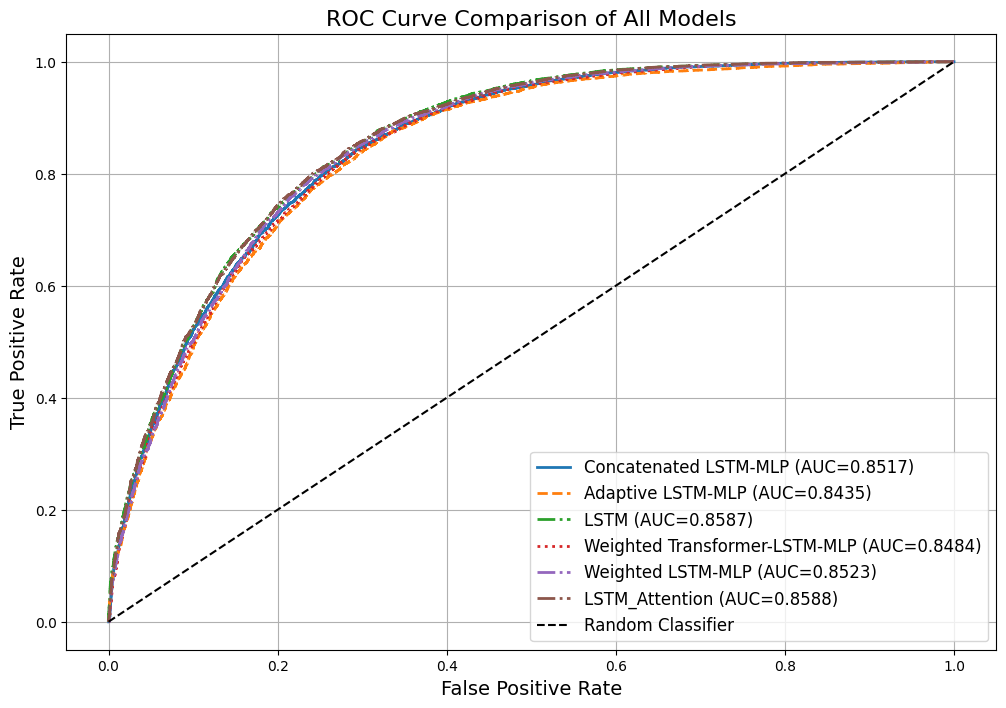

In [20]:
plt.figure(figsize=(12, 8))

# Plot each model's ROC curve
plt.plot(fpr_lstm_mlp, tpr_lstm_mlp, label=f'Concatenated LSTM-MLP (AUC={auc_lstm_mlp:.4f})', linestyle='-', linewidth=2)
plt.plot(fpr_conditional, tpr_conditional, label=f'Adaptive LSTM-MLP (AUC={auc_conditional:.4f})', linestyle='--', linewidth=2)
plt.plot(fpr_lstm_only, tpr_lstm_only, label=f'LSTM (AUC={auc_lstm_only:.4f})', linestyle='-.', linewidth=2)
plt.plot(fpr_transformer_lstm_mlp, tpr_transformer_lstm_mlp, label=f'Weighted Transformer-LSTM-MLP (AUC={auc_transformer_lstm_mlp:.4f})', linestyle=':', linewidth=2)
plt.plot(fpr_weighted_fusion, tpr_weighted_fusion, label=f'Weighted LSTM-MLP (AUC={auc_weighted_fusion:.4f})', linestyle='-.', linewidth=2)
plt.plot(fpr_lstm_attention, tpr_lstm_attention, label=f'LSTM_Attention (AUC={auc_lstm_attention:.4f})', linestyle='-.', linewidth=2)


# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier", linewidth=1.5)

# Formatting
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve Comparison of All Models', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)

# Show plot
plt.show()
